In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

In [2]:
train = pd.read_csv("/kaggle/input/hull-tactical-market-prediction/train.csv")
test = pd.read_csv("/kaggle/input/hull-tactical-market-prediction/test.csv")

In [3]:
train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


In [4]:
train.isnull().sum()

date_id                             0
D1                                  0
D2                                  0
D3                                  0
D4                                  0
                                 ... 
V8                               1006
V9                               4539
forward_returns                     0
risk_free_rate                      0
market_forward_excess_returns       0
Length: 98, dtype: int64

In [5]:
len(train)

9021

In [6]:
train.tail(10)

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
9011,9011,0,0,0,0,0,0,0,0,0,...,0.753968,0.389550,0.044475,0.647487,-0.225631,0.246693,-0.288534,-0.001222,0.000153,-0.001687
9012,9012,0,0,0,0,0,0,0,0,0,...,0.576058,0.418651,0.348617,0.503307,-0.002851,0.215608,-0.129058,0.004440,0.000153,0.003975
9013,9013,0,0,1,0,0,0,0,0,0,...,0.490741,0.416005,0.631288,0.648810,-0.024298,0.164021,-0.142364,-0.006810,0.000153,-0.007276
9014,9014,0,0,0,1,0,0,0,0,0,...,0.753968,0.445106,0.514279,0.681878,0.559650,0.116402,0.282344,0.005676,0.000153,0.005211
9015,9015,0,0,0,1,0,0,0,0,0,...,0.126984,0.445767,0.680419,0.564815,-0.007844,0.111111,-0.121647,0.010401,0.000152,0.009936
9016,9016,0,0,0,1,0,0,0,0,0,...,0.208995,0.484788,0.717308,0.677249,-0.327455,0.083995,-0.380452,-0.000015,0.000151,-0.000477
9017,9017,0,0,0,1,0,0,0,0,0,...,0.082011,0.482804,1.001028,0.596561,-0.372979,0.094246,-0.427355,-0.005199,0.000150,-0.005661
9018,9018,0,0,0,1,0,-1,0,0,0,...,0.334656,0.486772,0.894502,0.656746,-0.282024,0.090608,-0.381337,0.005930,0.000150,0.005467
9019,9019,0,0,0,1,0,-1,0,0,0,...,0.163360,0.492725,1.117639,0.674603,-0.445261,0.106481,-0.477635,0.008173,0.000150,0.007710
9020,9020,0,0,0,1,0,-1,0,0,0,...,0.177910,0.501323,1.231340,0.486111,-0.562036,0.089947,-0.543367,0.009524,0.000149,0.009062


In [7]:
test.head(10)

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V4,V5,V6,V7,V8,V9,is_scored,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
0,8980,0,0,0,0,1,0,0,1,0,...,0.828042,0.999172,0.759921,-0.803127,0.170966,-0.751909,True,0.003541,0.000161,0.003068
1,8981,0,0,0,0,1,0,0,1,0,...,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,True,-0.005964,0.000162,-0.006437
2,8982,0,0,0,0,1,0,0,0,1,...,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,True,-0.007410,0.000160,-0.007882
3,8983,0,0,0,0,1,0,0,0,1,...,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,True,0.005420,0.000160,0.004949
4,8984,0,0,0,0,0,0,1,0,1,...,0.839947,0.944593,0.715608,-0.692649,0.124669,-0.654045,True,0.008357,0.000159,0.007887
5,8985,0,0,0,0,0,0,0,0,0,...,0.837963,1.226772,0.822751,-0.707361,0.142857,-0.649616,True,-0.002896,0.000159,-0.003365
6,8986,0,0,0,0,0,0,0,0,0,...,0.837963,0.785877,0.805556,-0.715692,0.196098,-0.668289,True,0.002457,0.000155,0.001990
7,8987,0,0,1,0,0,0,0,0,0,...,0.787698,0.834898,0.823413,-0.723949,0.133929,-0.670946,True,0.002312,0.000156,0.001845
8,8988,0,0,0,0,0,0,0,0,0,...,0.783730,0.994026,0.851852,-0.684937,0.101852,-0.646265,True,0.002891,0.000156,0.002424
9,8989,0,0,0,0,0,0,0,0,0,...,0.783730,1.068037,0.879630,-0.764806,0.079034,-0.705662,False,0.008310,0.000156,0.007843


In [8]:
len(test)

10

In [9]:
train.columns

Index(['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1',
       'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19',
       'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3',
       'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13',
       'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7',
       'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5',
       'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4',
       'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2',
       'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns',
       'risk_free_rate', 'market_forward_excess_returns'],
      dtype='object')

# Market dynamics features

In [10]:
trainM = train.filter(like= 'M')
trainM.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,M1,M10,M11,M12,M13,M14,M15,M16,M17,M18,M2,M3,M4,M5,M6,M7,M8,M9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
trainM.isnull().sum()

M1     5547
M10    1006
M11    1006
M12    1006
M13    5540
M14    5540
M15    1006
M16    1006
M17    1006
M18    1006
M2     3217
M3     2018
M4     1006
M5     3283
M6     5043
M7     1006
M8     1006
M9     1006
dtype: int64

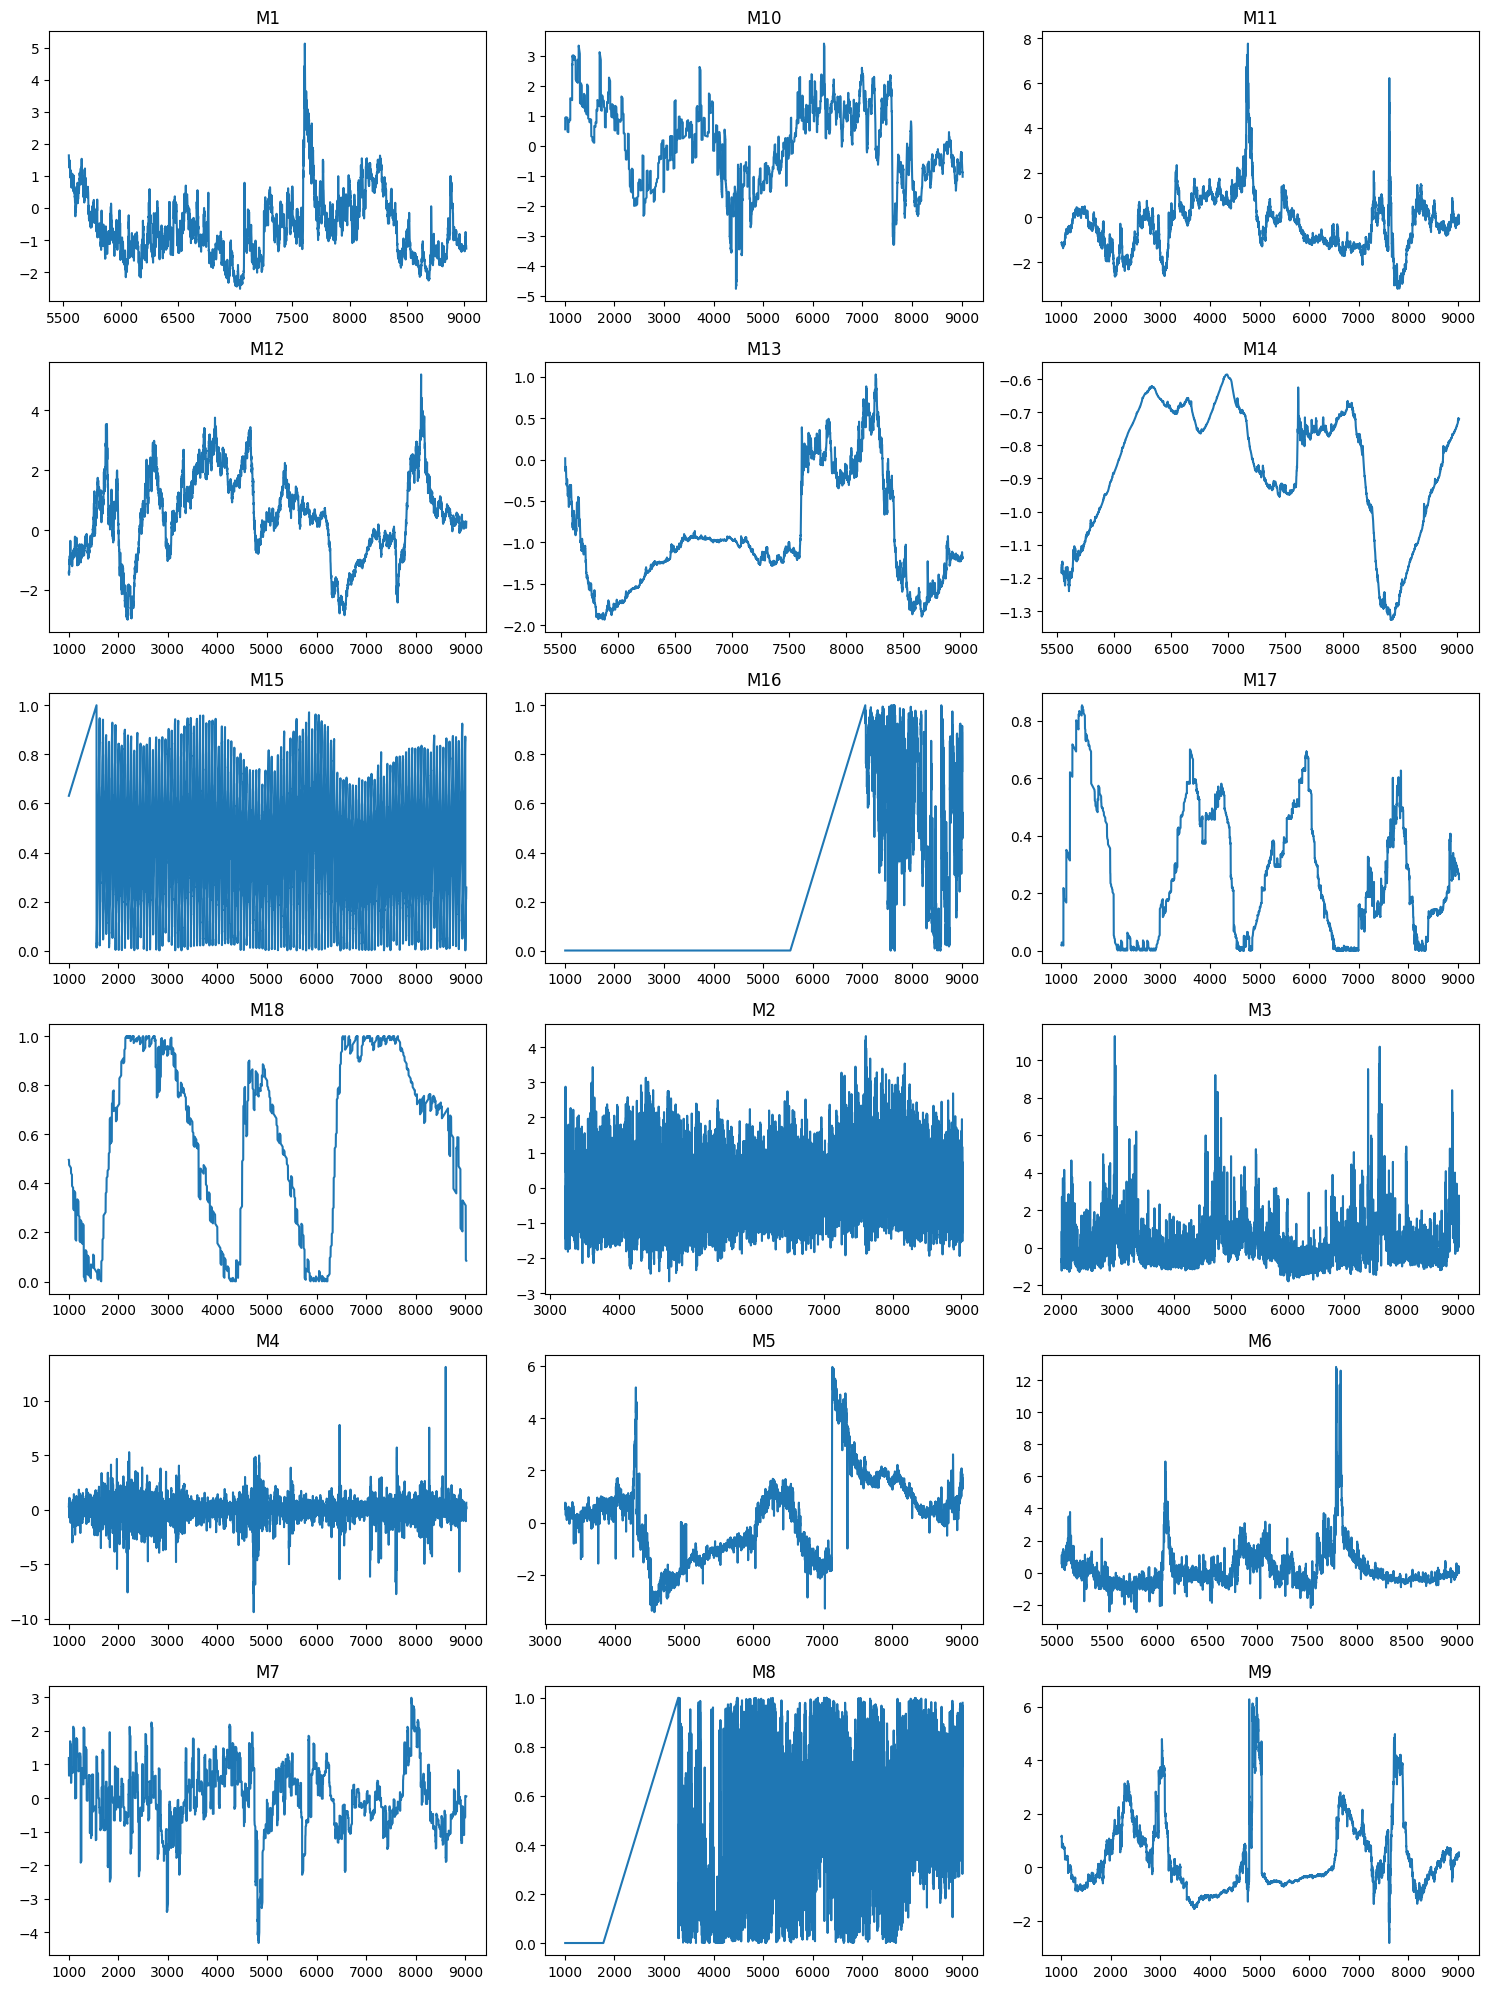

In [12]:
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15, 20)) # Example layout for 18 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(trainM.columns):
    trainM[col].plot(ax=axes[i], title=col) # Plot each column on its corresponding ax

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

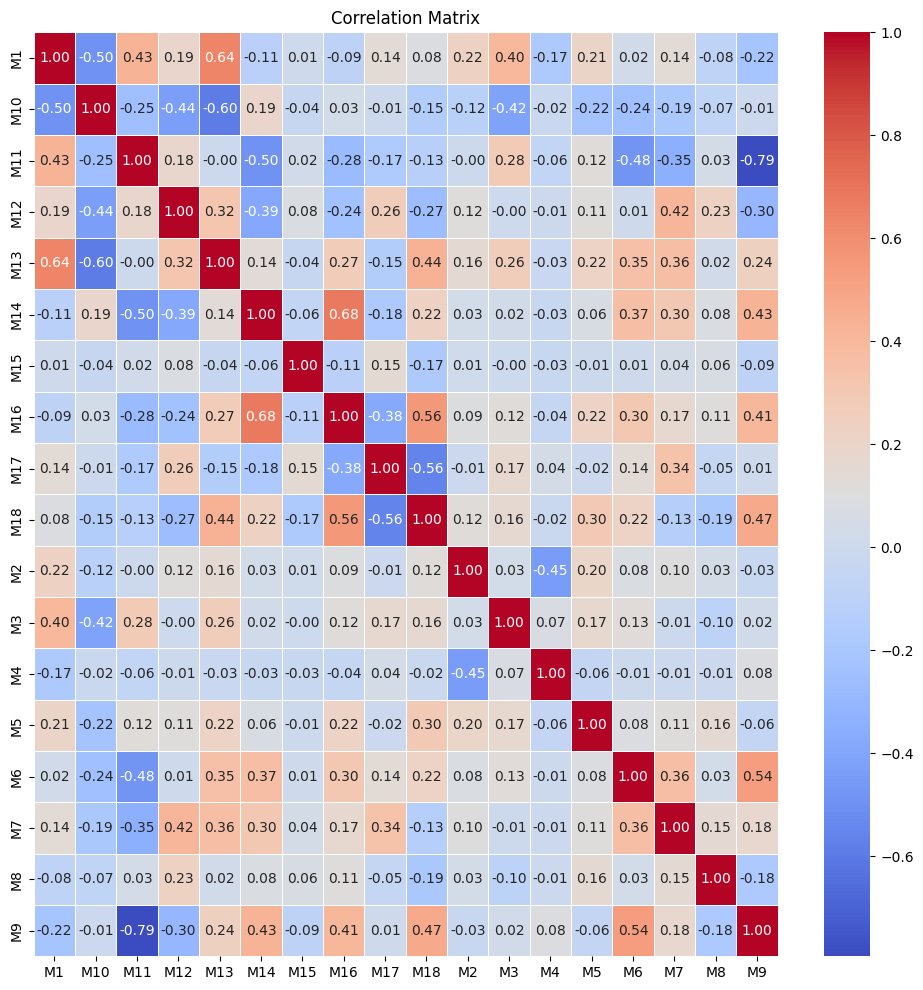

In [13]:
numeric_dataM = trainM.dropna(axis=0, inplace=False).select_dtypes(include=np.number)
correlation_matrix = numeric_dataM.corr()

# Plot the heatmap
plt.figure(figsize=(12, 12)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Macro Economic features

In [14]:
trainE = train.filter(like= 'E')

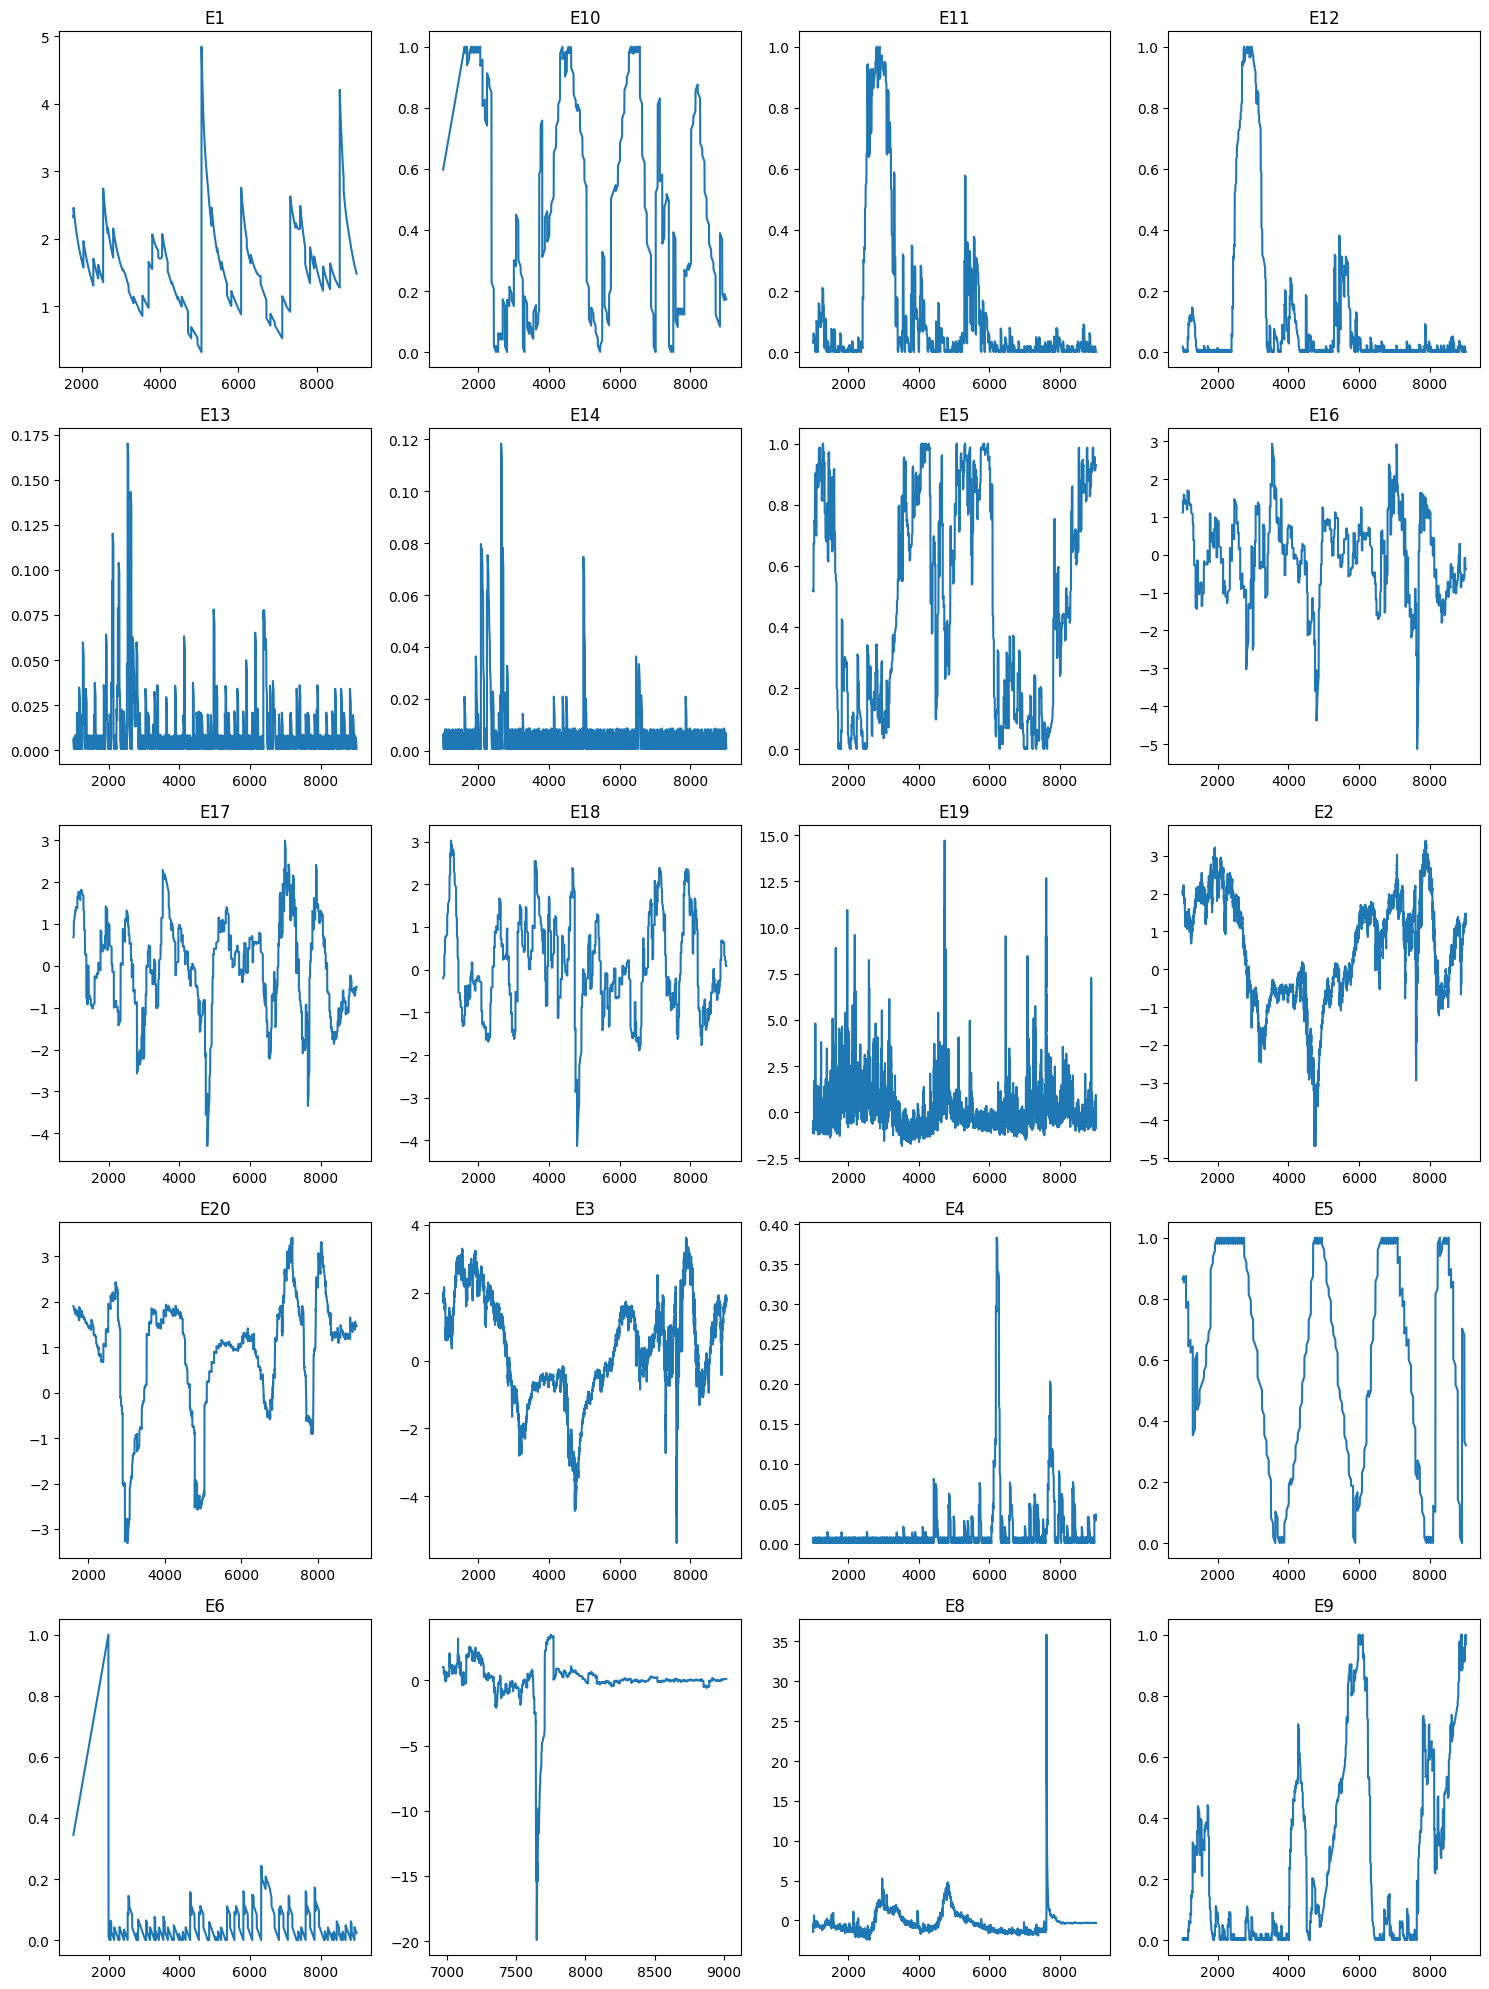

In [15]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15, 20)) # Example layout for 18 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(trainE.columns):
    trainE[col].plot(ax=axes[i], title=col) # Plot each column on its corresponding ax

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

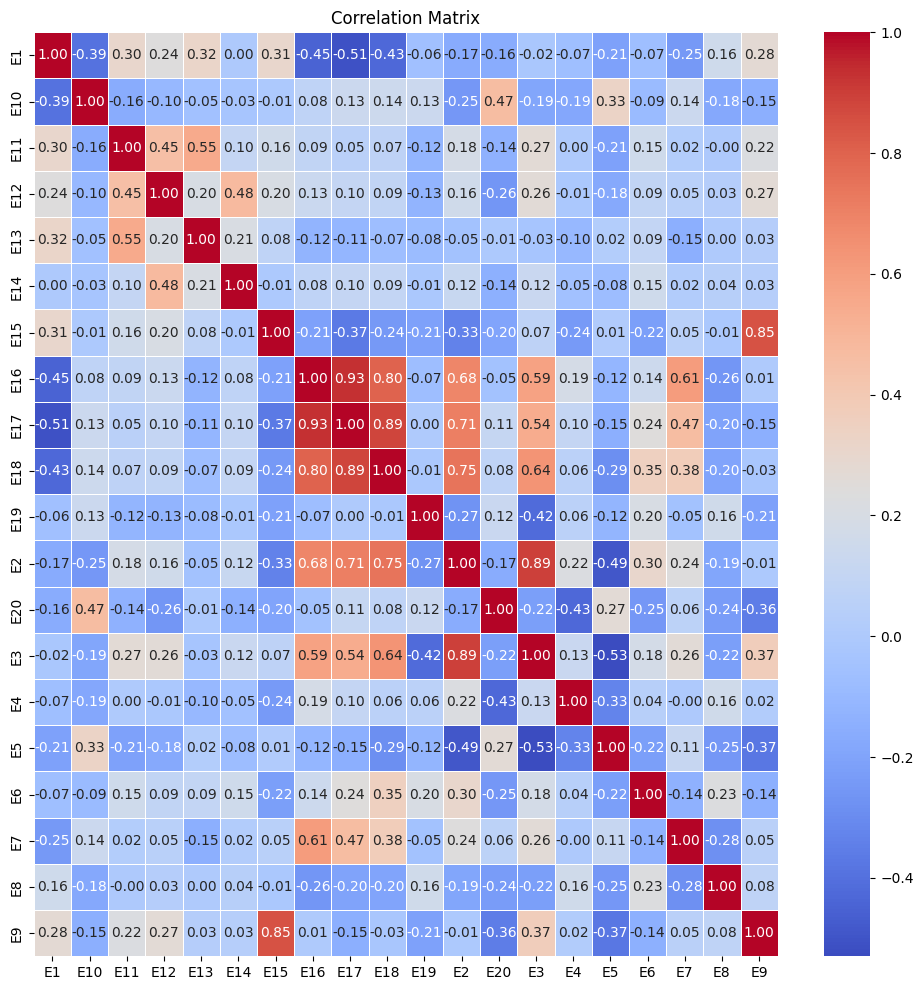

In [16]:
numeric_dataE = trainE.dropna(axis=0, inplace=False).select_dtypes(include=np.number)
correlation_matrix = numeric_dataE.corr()

# Plot the heatmap
plt.figure(figsize=(12, 12)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()